# M2 Initial Implementation

## Discovery Question 1:
*What 'staple' cards tend to be present in decks of the various color combinations?*

This question is essentialy asking what cards tend to be in the same deck. This is the same as the task of finding out what items tend to be in the same shopping cart which means that we can solve it the same way. I will use Apriori to find frequent item sets, and association rules to identify the cards that frequently appear together aka the 'staples'.

## Imports

In [1]:
import json
import glob
import os
import pandas
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

## Step 1: Load Supporting data from Previous Reorganization efforts

### Step 1.1: Load the AllCardsUUID.json and AllCardsName.json

In [2]:
SLIM_DECKS_PATH = '../Data/AllDeckFiles(slim)/'
ALL_CARDS_NAME_PATH = '../Data/AllCardsName.json'
ENCODING = 'utf-8'

with open(ALL_CARDS_NAME_PATH, 'r', encoding=ENCODING) as f:
    card_data = json.load(f)

card_lookup = {
    name: {
        'colorIdentity': info.get('colorIdentity', []),
        'types':         info.get('types', []),
        'manaValue':     info.get('manaValue', None),
    }
    for name, info in card_data.items()
}

print(f'Loaded lookup for {len(card_lookup):,} unique card names.')

Loaded lookup for 26,345 unique card names.


### Step 1.2: A helper function for more readable data
A key part of the question is associating 'staple' cards with certain color combinations. We can use these to make the color combinations more readable for the MTG format.

In [3]:
def color_label(colors):
    mapping = {
        frozenset():                  'Colorless',
        frozenset(['W']):             'Mono-White',
        frozenset(['U']):             'Mono-Blue',
        frozenset(['B']):             'Mono-Black',
        frozenset(['R']):             'Mono-Red',
        frozenset(['G']):             'Mono-Green',
        # Guild pairs
        frozenset(['W','U']):         'Azorius (WU)',
        frozenset(['W','B']):         'Orzhov (WB)',
        frozenset(['U','B']):         'Dimir (UB)',
        frozenset(['U','R']):         'Izzet (UR)',
        frozenset(['B','R']):         'Rakdos (BR)',
        frozenset(['B','G']):         'Golgari (BG)',
        frozenset(['R','G']):         'Gruul (RG)',
        frozenset(['R','W']):         'Boros (RW)',
        frozenset(['G','W']):         'Selesnya (GW)',
        frozenset(['G','U']):         'Simic (GU)',
        # Shards (arc/allied three-color)
        frozenset(['W','U','B']):     'Esper (WUB)',
        frozenset(['U','B','R']):     'Grixis (UBR)',
        frozenset(['B','R','G']):     'Jund (BRG)',
        frozenset(['R','G','W']):     'Naya (RGW)',
        frozenset(['G','W','U']):     'Bant (GWU)',
        # Wedges (enemy three-color)
        frozenset(['W','B','R']):     'Mardu (WBR)',
        frozenset(['U','R','G']):     'Temur (URG)',
        frozenset(['B','G','W']):     'Abzan (BGW)',
        frozenset(['R','W','U']):     'Jeskai (RWU)',
        frozenset(['G','U','B']):     'Sultai (GUB)',
        # Four-color (Nephilim)
        frozenset(['W','U','B','R']): 'Artifice (WUBR)',
        frozenset(['U','B','R','G']): 'Chaos (UBRG)',
        frozenset(['B','R','G','W']): 'Aggression (BRGW)',
        frozenset(['R','G','W','U']): 'Altruism (RGWU)',
        frozenset(['G','W','U','B']): 'Growth (GWUB)',
    }
    key = frozenset(colors)
    if key in mapping:
        return mapping[key]
    if len(key) >= 5:
        return '5-Color (WUBRG)'
    return 'Other'

## Step 1.3: Load the deck .json files

In [4]:
CARD_SECTIONS = ['commander', 'mainBoard']
records = []
skipped = 0

for filepath in glob.glob(f'{SLIM_DECKS_PATH}*.json'):
    with open(filepath, 'r', encoding=ENCODING) as f:
        raw = json.load(f)

    deck = raw.get('data', raw)

    #Combine card sets from selected card containing sections
    all_cards = [card for section in CARD_SECTIONS for card in deck.get(section, [])]
    card_names = [c['name'] for c in all_cards if 'name' in c]

    #Determine colorIdentity for deck
    all_colors = set()
    for name in card_names:
        info = card_lookup.get(name)
        if info:
            all_colors.update(info['colorIdentity'])

    deck_size = sum(c.get('count', 1) for c in all_cards)

    if deck_size < 21: #very important that we do this to filter Jumpstart releases which greatly skew results for mono-color decks
        skipped += 1
        continue
    
    records.append({
        'deck_name': deck.get('name', os.path.basename(filepath)),
        'deck_type':      deck.get('type', 'Unknown'),
        'releaseDate':    deck.get('releaseDate', None),
        'card_names':     card_names,
        'deck_size':      deck_size,
        'color_identity': color_label(all_colors),
    })

decks_df = pandas.DataFrame(records)
decks_df['releaseDate'] = pandas.to_datetime(decks_df['releaseDate'], errors='coerce')
decks_df['releaseYear'] = decks_df['releaseDate'].dt.year

print(f'Decks loaded: {len(records)}')
print(f'Decks skipped: {skipped}')
print(f'Date range:    {decks_df["releaseDate"].min().date()} to {decks_df["releaseDate"].max().date()}')
decks_df[['deck_name','deck_type','releaseDate','deck_size','color_identity']].head()

Decks loaded: 1377
Decks skipped: 1277
Date range:    1993-12-10 to 2026-01-23


,deck_name,deck_type,releaseDate,deck_size,color_identity
0,20 Ways to Win,Commander Deck,2024-12-04,100,5-Color (WUBRG)
1,30th Anniversary Countdown Kit,Secret Lair Drop,2022-11-01,30,5-Color (WUBRG)
2,Abzan Armor,Commander Deck,2025-04-11,100,Abzan (BGW)
3,Abzan Siege,Intro Pack,2014-09-26,60,Abzan (BGW)
4,Adaptive Enchantment,Commander Deck,2018-08-10,100,Bant (GWU)


## Step 2: EDA
### Step 2.1: Scope
First we lay out the scope of the data, so that we can make informed choices for the thresholds of the Aprioiri.

Total decks:          1,377
Unique deck types:    40
Color identities:     32
Total card occurances: 91,732
Unique card names:    25,213
Avg deck size:        88.9 cards
Min/Max deck size:    21 / 387


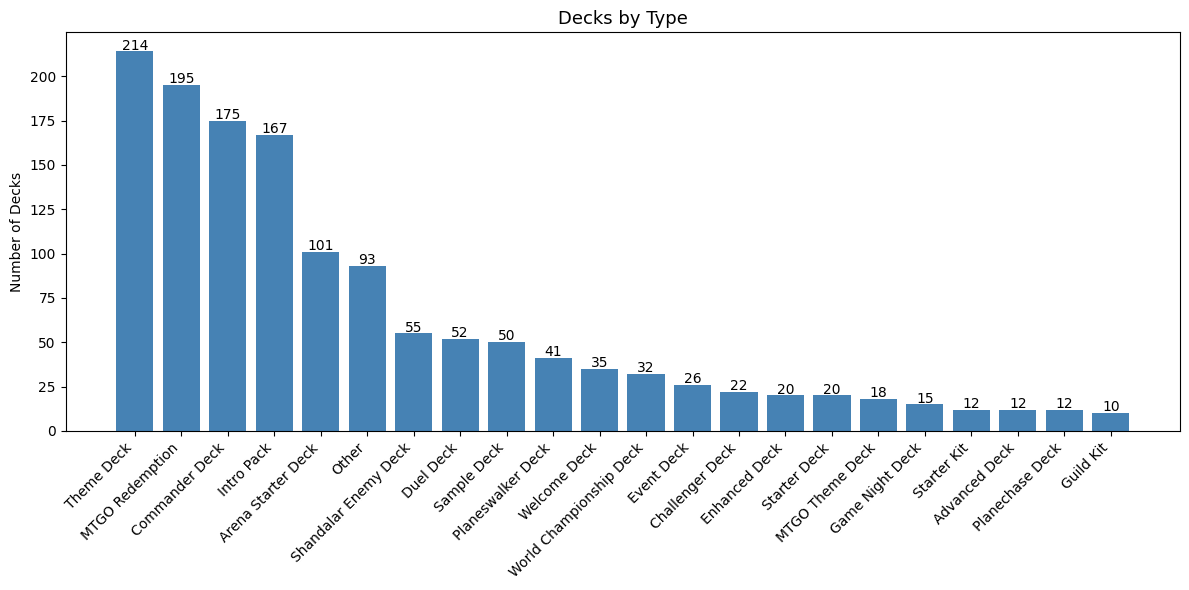

In [5]:
all_occurrences = [name for names in decks_df['card_names'] for name in names]
card_freq = Counter(all_occurrences)

print(f'Total decks:          {len(decks_df):,}')
print(f'Unique deck types:    {decks_df["deck_type"].nunique()}')
print(f'Color identities:     {decks_df["color_identity"].nunique()}')
print(f'Total card occurances: {len(all_occurrences):,}')
print(f'Unique card names:    {len(card_freq):,}')
print(f'Avg deck size:        {decks_df["deck_size"].mean():.1f} cards')
print(f'Min/Max deck size:    {decks_df["deck_size"].min()} / {decks_df["deck_size"].max()}')

type_counts = decks_df['deck_type'].value_counts()
type_counts_filtered = type_counts[type_counts >= 10]
other_count = type_counts[type_counts < 10].sum()
if other_count > 0:
    type_counts_filtered['Other'] = other_count
type_counts_filtered = type_counts_filtered.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(type_counts_filtered.index, type_counts_filtered.values, color='steelblue')
ax.set_title('Decks by Type', fontsize=13)
ax.set_ylabel('Number of Decks')
for i, v in enumerate(type_counts_filtered.values):
    ax.text(i, v + 1, str(v), ha='center')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 2.2: Variety
What differnt deck formats are present and how many color combinations do we have?

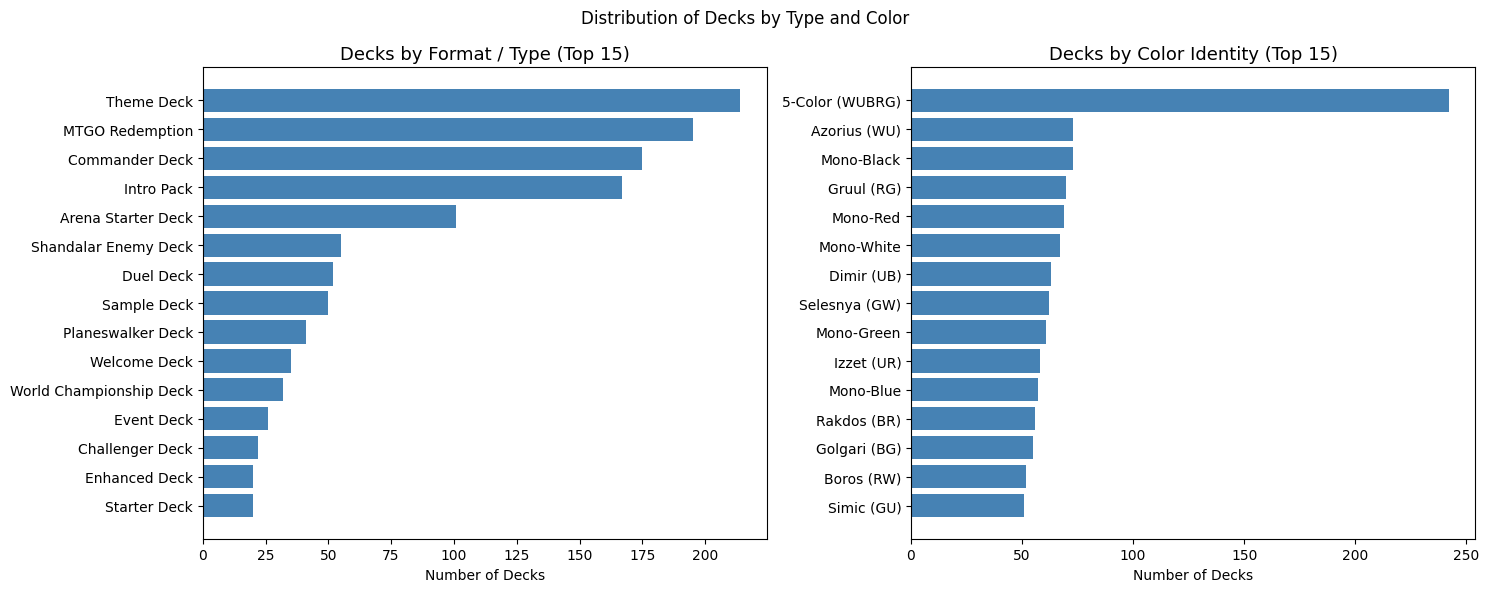

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

type_counts = decks_df['deck_type'].value_counts().head(15)
axes[0].barh(type_counts.index[::-1], type_counts.values[::-1], color='steelblue')
axes[0].set_title('Decks by Format / Type (Top 15)', fontsize=13)
axes[0].set_xlabel('Number of Decks')

color_counts = decks_df['color_identity'].value_counts().head(15)
axes[1].barh(color_counts.index[::-1], color_counts.values[::-1], color='steelblue')
axes[1].set_title('Decks by Color Identity (Top 15)', fontsize=13)
axes[1].set_xlabel('Number of Decks')

plt.suptitle('Distribution of Decks by Type and Color', fontsize=12)
plt.tight_layout()
plt.savefig('eda_deck_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2.3: Generaly Frequent Cards
What cards appear most often regardless of pairing, excluding basic lands?

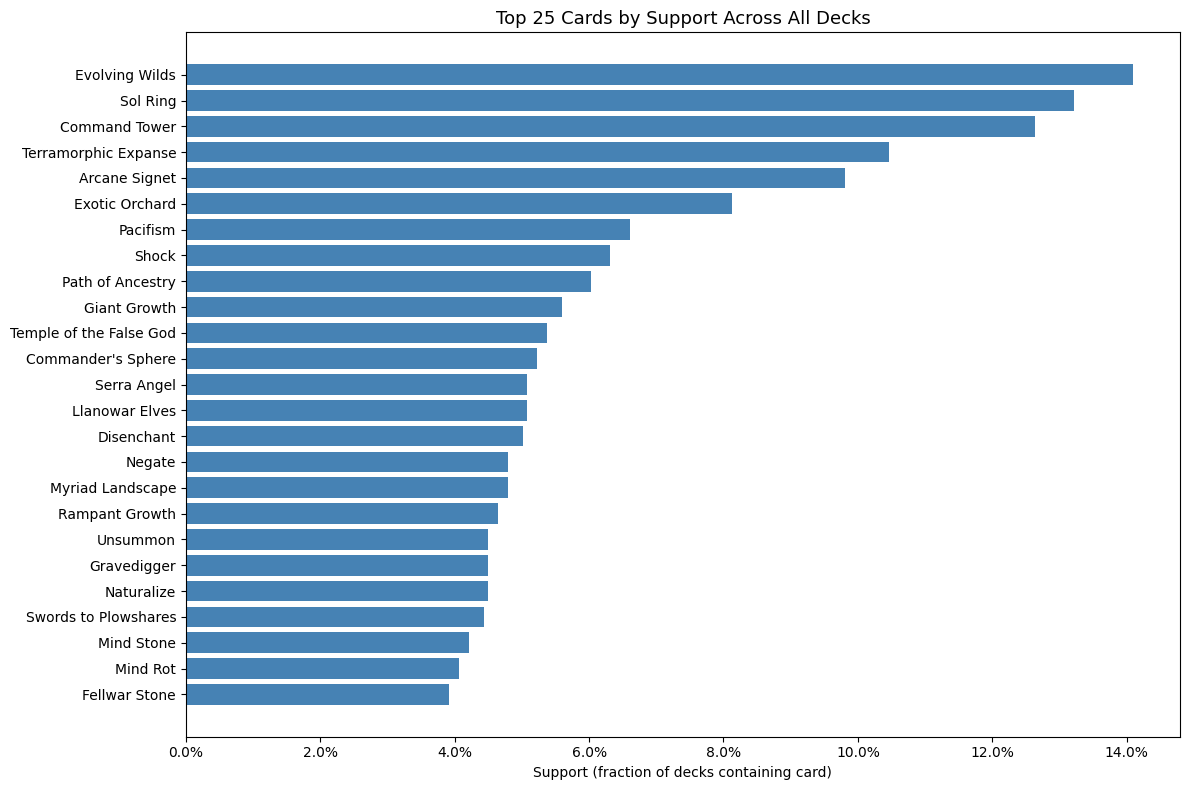

In [7]:
BASIC_LANDS = {'Plains', 'Island', 'Swamp', 'Mountain', 'Forest', 'Wastes', 'Snow-Covered Plains', 'Snow-Covered Island', 'Snow-Covered Swamp','Snow-Covered Mountain', 'Snow-Covered Forest'}

top_n = 25
top_cards = top_cards = pandas.DataFrame([(card, count) for card, count in card_freq.most_common() if card not in BASIC_LANDS],columns=['card', 'count']).head(top_n)
top_cards['support'] = top_cards['count'] / len(decks_df)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_cards['card'][::-1], top_cards['support'][::-1], color='steelblue')
ax.set_title(f'Top {top_n} Cards by Support Across All Decks', fontsize=13)
ax.set_xlabel('Support (fraction of decks containing card)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('eda_top_cards_overall.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2.4: Frequency of new releases
How many decks were released each year?

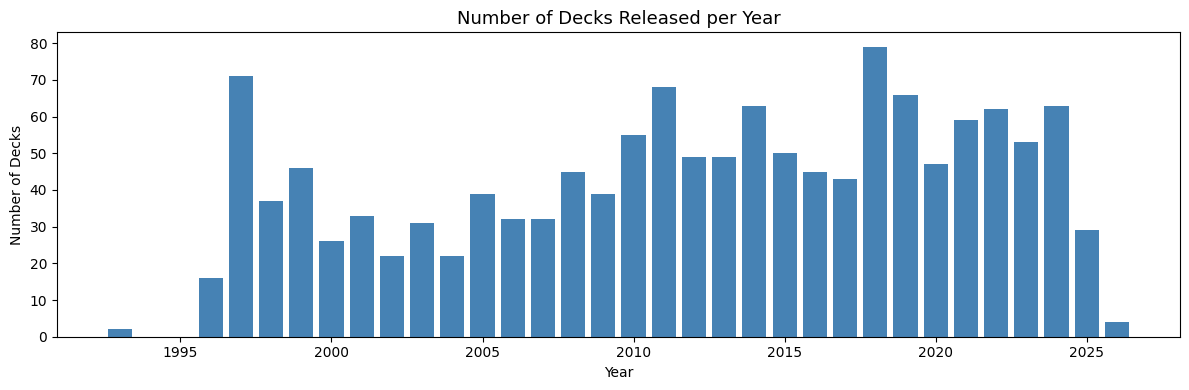

In [8]:
year_counts = decks_df['releaseYear'].value_counts().sort_index().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(year_counts.index.astype(int), year_counts.values, color='steelblue')
ax.set_title('Number of Decks Released per Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Decks')
plt.tight_layout()
plt.savefig('eda_decks_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2.5: Sparsity Check
In order to determine our minimum support threshold we will examine the distribution of card frequencies.

Cards appearing in at least N decks:
  >=   1 decks (support >= 0.001): 25,213 cards (100.0% of unique cards)
  >=   2 decks (support >= 0.001): 21,006 cards (83.3% of unique cards)
  >=   5 decks (support >= 0.004): 3,643 cards (14.4% of unique cards)
  >=  10 decks (support >= 0.007):   873 cards (3.5% of unique cards)
  >=  20 decks (support >= 0.015):   247 cards (1.0% of unique cards)
  >=  50 decks (support >= 0.036):    33 cards (0.1% of unique cards)


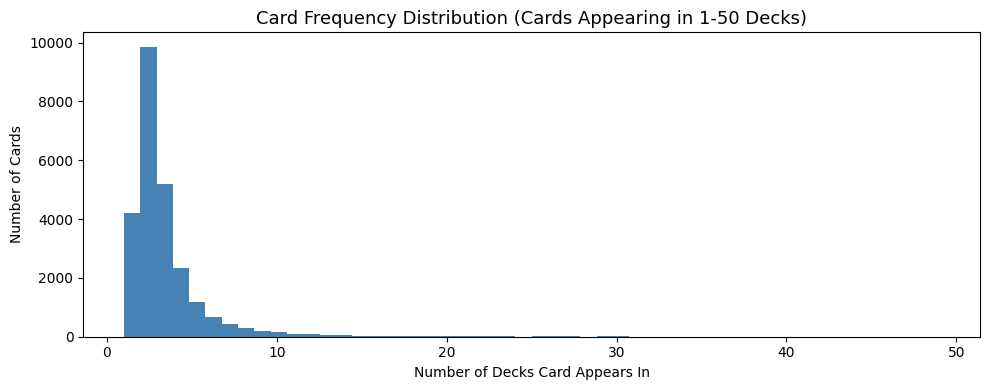

In [9]:
freq_values = list(card_freq.values())

thresholds = [1, 2, 5, 10, 20, 50]
print('Cards appearing in at least N decks:')
for t in thresholds:
    n = sum(1 for v in freq_values if v >= t)
    pct = n / len(card_freq) * 100
    support = t / len(decks_df)
    print(f'  >= {t:3d} decks (support >= {support:.3f}): {n:5,} cards ({pct:.1f}% of unique cards)')

fig, ax = plt.subplots(figsize=(10, 4))
filtered_freq = [v for v in freq_values if v <= 50]
ax.hist(filtered_freq, bins=50, color='steelblue')
ax.set_title('Card Frequency Distribution (Cards Appearing in 1-50 Decks)', fontsize=13)
ax.set_xlabel('Number of Decks Card Appears In')
ax.set_ylabel('Number of Cards')
plt.tight_layout()
plt.savefig('eda_card_freq_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Preprocessing
**Decisions and rationale:**

1. Minimum deck size >= 20: Applied at load time. Removes incomplete/placeholder deck files and small collector's releases that would create noise without contributing real card co-occurrence data.

2. Remove basic lands: Plains, Island, Swamp, Mountain, Forest and their snow-covered variants are excluded from transactions as they will appear in most decks and generate technically real but useluss relationships.

3. Deduplicate card names per deck: A card appearing 4 times in a deck (e.g., in a 60-card format) is treated identically to one appearing once. We are mining for *presence*, not quantity.

In [10]:
def clean_transaction(names):
    return list(set(n for n in names if n not in BASIC_LANDS))

decks_df['transaction'] = decks_df['card_names'].apply(clean_transaction)
decks_df['transaction_size'] = decks_df['transaction'].apply(len)

print(f'Avg transaction size after cleaning: {decks_df["transaction_size"].mean():.1f} unique non-land cards')
print(f'Decks after preprocessing: {len(decks_df)}')

Avg transaction size after cleaning: 59.4 unique non-land cards
Decks after preprocessing: 1377


In [11]:
def encode_transactions(transaction_list):
    te = TransactionEncoder()
    te_array = te.fit(transaction_list).transform(transaction_list)
    return pandas.DataFrame(te_array, columns=te.columns_)

print('Encoding all transactions...')
te_df_all = encode_transactions(decks_df['transaction'].tolist())
sparsity = 1 - te_df_all.values.mean()
print(f'Encoded matrix: {te_df_all.shape[0]} decks x {te_df_all.shape[1]} unique cards')
print(f'Matrix sparsity: {sparsity:.1%} (most cells are False — expected for card data)')

Encoding all transactions...
Encoded matrix: 1377 decks x 25202 unique cards
Matrix sparsity: 99.8% (most cells are False — expected for card data)


## Step 4: Mining: Apriori + Association Rules

### Why Apriori?
Apriori is a well-established algorithm for problems like determining items in a cart that uses a bottom-up candidate generation approach. At our dataset size, runtime is not a concern so Apriori will work just as well as FP-Growth.

### Why Association Rules for this question?
Mainly because I was told I should focus on this in my feedback for M1. However, after seeing the relation ship between my problems and ones talked about in the reading, I see how the approach to this should be identical to the items in a cart problem.

### Threshold rationale
- **min_support = 0.009** (0.9%): A card appearing in 12 of 1,377 decks is meaningfully recurring. The sparsity check above (Step 3.2) confirms this catches a useful number of cards without drowning in noise.
- **min_confidence = 0.40**: Given card X is in a deck, card Y appears 40%+ of the time. Balances interestingness with coverage.
- **lift > 1.1**: Filters rules that are only explained by each card's individual popularity — we want pairs co-occurring *more than chance would predict*.

### Step 4.1: Global Patterns
In order to assure that are patterns for specific colors aren't echos of general popularity. We will need to see what cards occur frequently across color types.

In [12]:
MIN_SUPPORT    = 0.009
MIN_CONFIDENCE = 0.40
MIN_LIFT       = 1.1

min_count = int(MIN_SUPPORT * len(te_df_all))
frequent_cols = te_df_all.columns[te_df_all.sum() >= min_count]
te_df_filtered = te_df_all[frequent_cols]
print(f'Reduced matrix: {te_df_filtered.shape[0]} decks x {te_df_filtered.shape[1]} unique cards')
print(f'Filtered matrix columns: {te_df_filtered.shape[1]}')

print('Running Apriori on all decks...')
freq_items_all = apriori(te_df_filtered, min_support=MIN_SUPPORT, use_colnames=True)
freq_items_all = freq_items_all.sort_values('support', ascending=False)
print(f'Frequent itemsets found: {len(freq_items_all):,}')

rules_all = association_rules(freq_items_all, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules_all = rules_all[rules_all['lift'] >= MIN_LIFT].sort_values('lift', ascending=False)
print(f'Association rules found: {len(rules_all):,}')

# Preview top rules
display_rules = rules_all[['antecedents','consequents','support','confidence','lift']].copy()
display_rules['antecedents'] = display_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
display_rules['consequents'] = display_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
display_rules.head(15)

Reduced matrix: 1377 decks x 607 unique cards
Filtered matrix columns: 607
Running Apriori on all decks...
Frequent itemsets found: 5,662
Association rules found: 92,096


,antecedents,consequents,support,confidence,lift
91912,"Giant Spider, Lava Axe, Lightning Elemental, P...","Gravedigger, Rampant Growth, Serra Angel",0.009441,1.0,105.923077
90494,"Gravedigger, Pacifism, Rampant Growth","Lava Axe, Lightning Elemental, Serra Angel",0.009441,1.0,105.923077
89830,"Giant Spider, Lightning Elemental, Serra Angel","Gravedigger, Lava Axe, Rampant Growth",0.009441,1.0,105.923077
89831,"Gravedigger, Lightning Elemental, Serra Angel","Giant Spider, Lava Axe, Rampant Growth",0.009441,1.0,105.923077
90492,"Gravedigger, Lightning Elemental, Pacifism","Lava Axe, Rampant Growth, Serra Angel",0.009441,1.0,105.923077
90491,"Gravedigger, Lava Axe, Rampant Growth","Lightning Elemental, Pacifism, Serra Angel",0.009441,1.0,105.923077
91958,"Giant Spider, Gravedigger, Lightning Elemental","Lava Axe, Pacifism, Rampant Growth, Serra Angel",0.009441,1.0,105.923077
89834,"Giant Spider, Rampant Growth, Serra Angel","Gravedigger, Lava Axe, Lightning Elemental",0.009441,1.0,105.923077
89835,"Gravedigger, Rampant Growth, Serra Angel","Giant Spider, Lava Axe, Lightning Elemental",0.009441,1.0,105.923077
91972,"Lightning Elemental, Pacifism","Giant Spider, Gravedigger, Lava Axe, Rampant G...",0.009441,1.0,105.923077


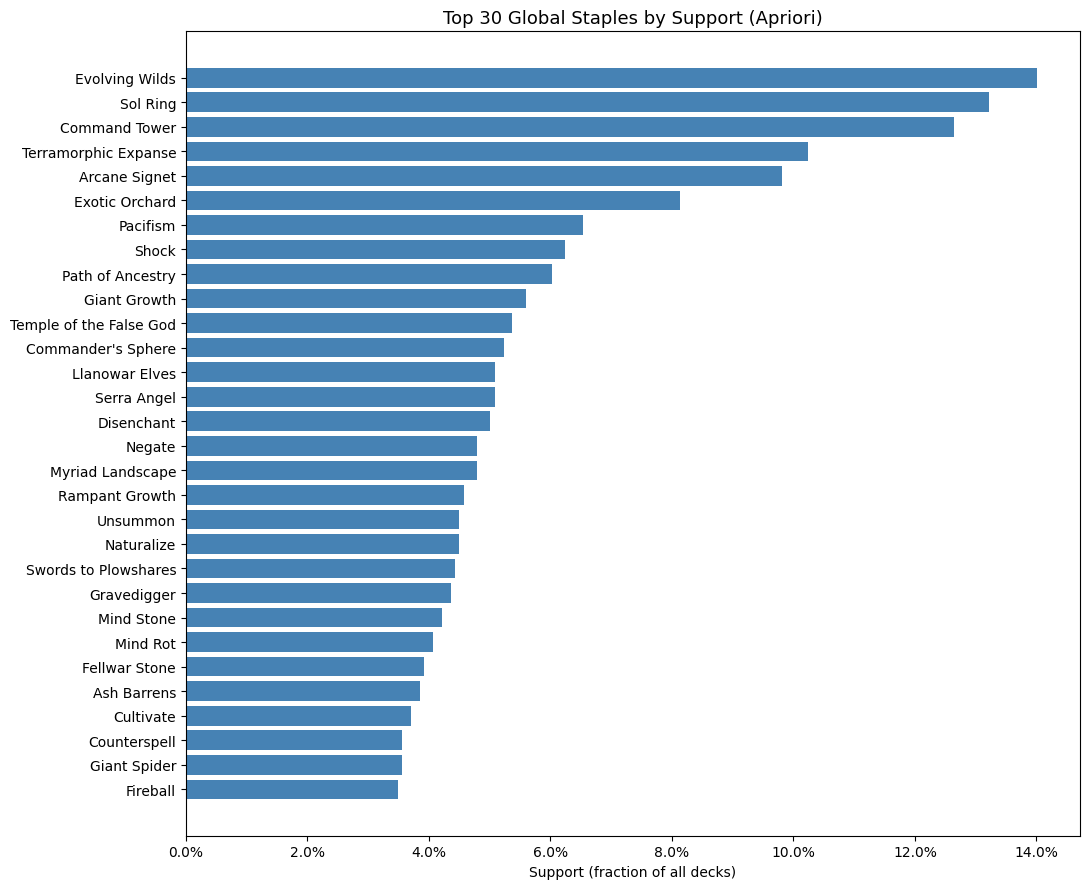

In [13]:
single_items = freq_items_all[freq_items_all['itemsets'].apply(lambda x: len(x) == 1)].copy()
single_items['card'] = single_items['itemsets'].apply(lambda x: list(x)[0])
top_staples = single_items.sort_values('support', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(top_staples['card'][::-1], top_staples['support'][::-1], color='steelblue')
ax.set_title('Top 30 Global Staples by Support (Apriori)', fontsize=13)
ax.set_xlabel('Support (fraction of all decks)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('mining_global_staples.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 4.2: Color Specifc

In [14]:
MIN_DECKS_PER_COLOR = 15

valid_colors = (
    decks_df['color_identity'].value_counts()
    .pipe(lambda s: s[s >= MIN_DECKS_PER_COLOR])
    .index.tolist()
)
print(f'Color groups with >= {MIN_DECKS_PER_COLOR} decks: {len(valid_colors)}')

color_staples = {}
color_rules   = {}

for color in valid_colors:
    subset = decks_df[decks_df['color_identity'] == color]
    transactions = subset['transaction'].tolist()
    n = len(transactions)

    # Use a slightly lower support floor for smaller color groups
    local_support = max(0.10, 5 / n)

    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    te_df = pandas.DataFrame(te_array, columns=te.columns_)

    freq = apriori(te_df, min_support=local_support, use_colnames=True)
    if freq.empty:
        continue

    singles = freq[freq['itemsets'].apply(lambda x: len(x) == 1)].copy()
    singles['card'] = singles['itemsets'].apply(lambda x: list(x)[0])
    color_staples[color] = singles.sort_values('support', ascending=False).head(20)

    if len(freq) > 1:
        try:
            rules = association_rules(freq, metric='confidence', min_threshold=MIN_CONFIDENCE)
            rules = rules[rules['lift'] >= MIN_LIFT]
            color_rules[color] = rules.sort_values('lift', ascending=False)
        except Exception:
            pass

    print(f'{color:30s} | {n:4d} decks | {len(singles):4d} frequent cards | support >= {local_support:.2f}')

Color groups with >= 15 decks: 25
5-Color (WUBRG)                |  242 decks |   14 frequent cards | support >= 0.10
Azorius (WU)                   |   73 decks |    7 frequent cards | support >= 0.10
Mono-Black                     |   73 decks |   18 frequent cards | support >= 0.10
Gruul (RG)                     |   70 decks |    8 frequent cards | support >= 0.10
Mono-Red                       |   69 decks |   16 frequent cards | support >= 0.10
Mono-White                     |   67 decks |   10 frequent cards | support >= 0.10
Dimir (UB)                     |   63 decks |   11 frequent cards | support >= 0.10
Selesnya (GW)                  |   62 decks |   10 frequent cards | support >= 0.10
Mono-Green                     |   61 decks |   10 frequent cards | support >= 0.10
Izzet (UR)                     |   58 decks |   15 frequent cards | support >= 0.10
Mono-Blue                      |   57 decks |   16 frequent cards | support >= 0.10
Rakdos (BR)                    |   56 deck

#### Step 4.2.1 Visualization of Color Specific Mining
Charts are orderd top to bottom left to right for color groups with the lowest support to the highest

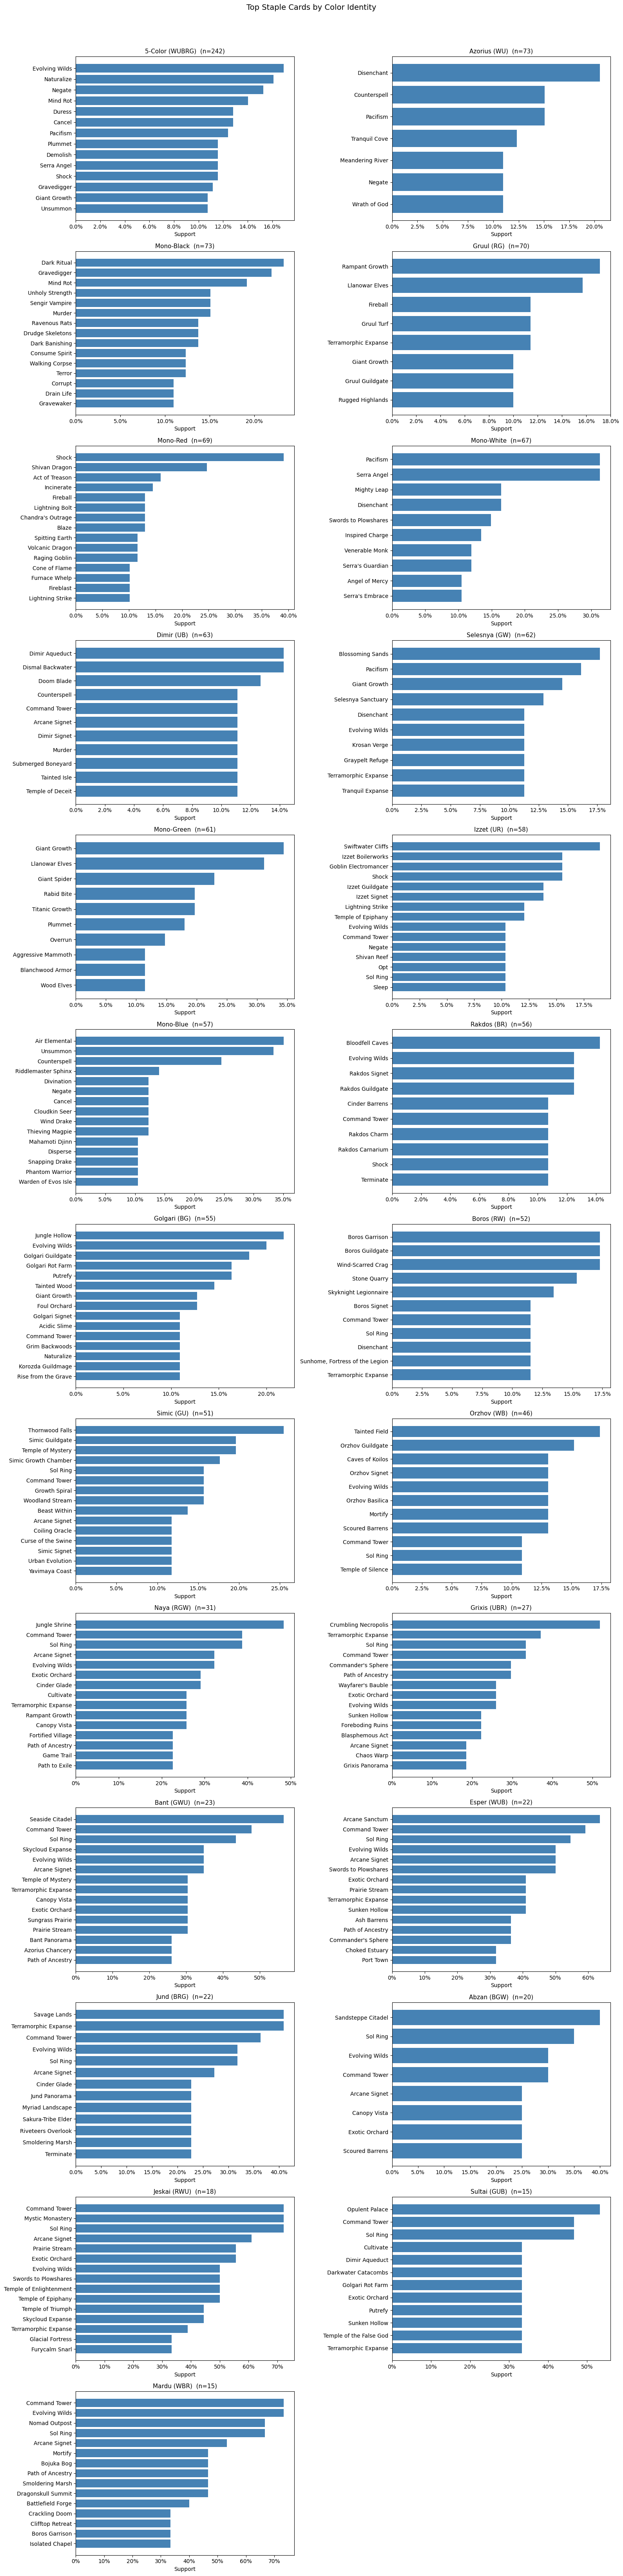

In [52]:
top_colors_to_plot = (
    decks_df['color_identity'].value_counts()
    .loc[lambda s: s.index.isin(color_staples.keys())]
    .index.tolist()[:25]
)

n_cols = 2
n_rows = (len(top_colors_to_plot) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, color in enumerate(top_colors_to_plot):
    df = color_staples[color].head(15)
    axes[i].barh(df['card'][::-1], df['support'][::-1], color='steelblue')
    n_decks = len(decks_df[decks_df['color_identity'] == color])
    axes[i].set_title(f'{color}  (n={n_decks})', fontsize=11)
    axes[i].set_xlabel('Support')
    axes[i].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for j in range(len(top_colors_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Staple Cards by Color Identity', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('mining_staples_by_color.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 4.3 Heatmap for staples across group

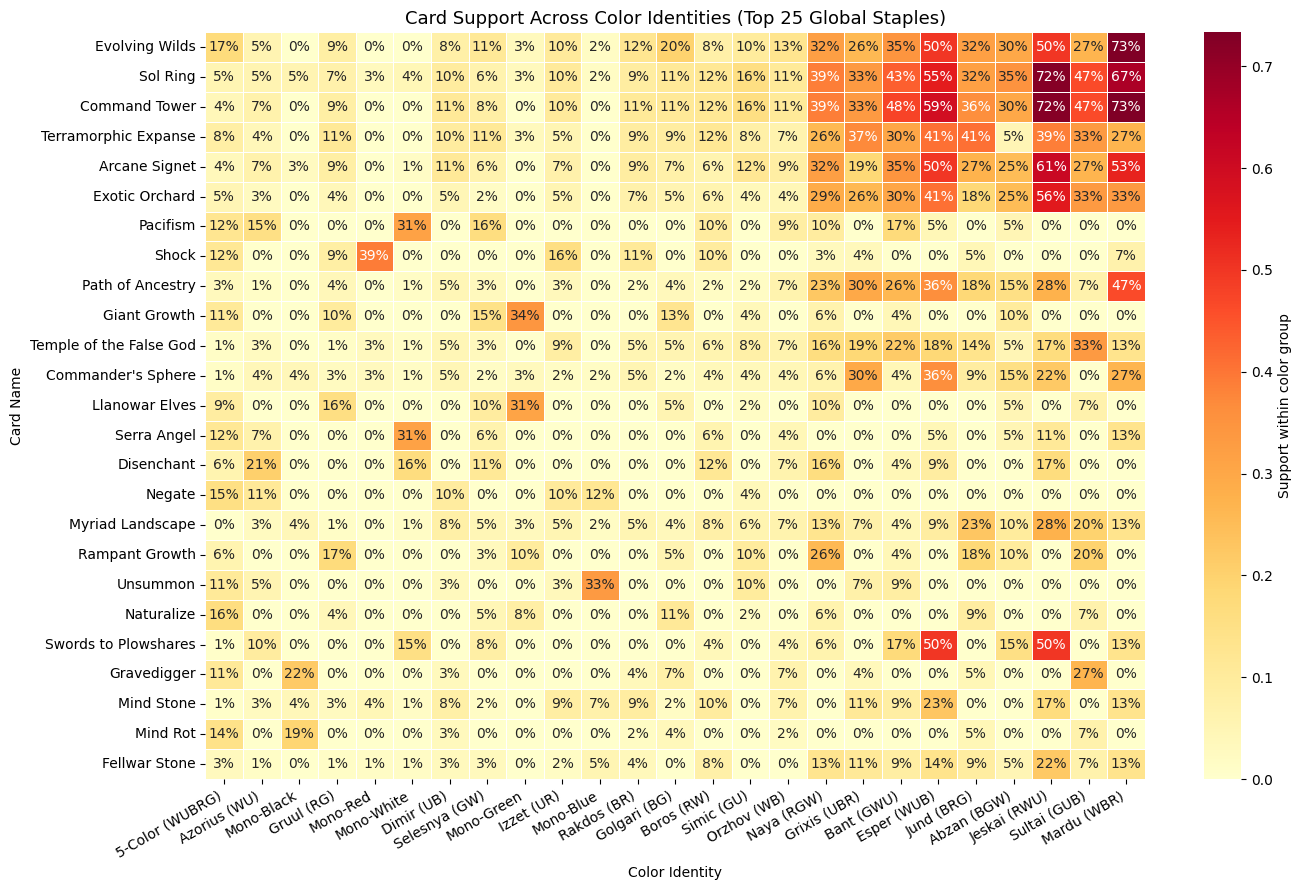

In [53]:
top_global_cards = top_staples['card'].tolist()[:25]

heatmap_data = {}
for color in top_colors_to_plot:
    subset = decks_df[decks_df['color_identity'] == color]
    n = len(subset)
    col_freq = Counter(name for names in subset['transaction'] for name in names)
    heatmap_data[color] = {card: col_freq.get(card, 0) / n for card in top_global_cards}

heatmap_df = pandas.DataFrame(heatmap_data, index=top_global_cards)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(heatmap_df, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Support within color group'})
ax.set_title('Card Support Across Color Identities (Top 25 Global Staples)', fontsize=13)
ax.set_xlabel('Color Identity')
ax.set_ylabel('Card Name')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('mining_staple_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Preliminary Findings

In [56]:
print('Universal Staples (support >= 10% across all decks):')
universal = single_items[single_items['support'] >= 0.10].sort_values('support', ascending=False)
print(universal[['card','support']].to_string(index=False))

print()
print('Color-Specific Staples (appear in top staples for only 1-2 color groups):')
card_color_count = Counter()
for color, df in color_staples.items():
    for card in df['card']:
        card_color_count[card] += 1

color_specific = [(card, cnt) for card, cnt in card_color_count.items() if cnt <= 2]
print(f'{len(color_specific)} cards appear as top staples in only 1-2 color groups.')
print('Examples:', [c for c,_ in color_specific[:10]])

Universal Staples (support >= 10% across all decks):
                card  support
      Evolving Wilds 0.140160
            Sol Ring 0.132171
       Command Tower 0.126362
Terramorphic Expanse 0.102397

Color-Specific Staples (appear in top staples for only 1-2 color groups):
189 cards appear as top staples in only 1-2 color groups.
Examples: ['Naturalize', 'Mind Rot', 'Duress', 'Cancel', 'Plummet', 'Demolish', 'Serra Angel', 'Gravedigger', 'Unsummon', 'Tranquil Cove']


## Interpretation
### Key Finding 1 — Universal staples are confirmed.
Cards like *Evolving Wilds*, *Sol Ring*, *Command Tower*, and *Terramorphic Expanse* appear across 10% of all decks, confirming community knowledge that certain cards are near-automatic inclusions. This finding makes sense, as these cards can provide signifigant benifit in any deck most decks they are put in. Additionally, most are limited to commander, explaining why they have such a low support despite being the highest support.

### Key Finding 2 — Color-specific staples are identifiable and meaningful for some colors but not all.
The per-color heatmap reveals cards that spike sharply in one color group but are absent from others. There are a few stand out cards with strong support for being paired with a specific color identity: *Shock* in Mono-Red at 39%, *Serra Angel* and *Pacifism* in Mono-White both at 31%, Strong ramp cards *Giant Growth* and *Llanowar Elves* in Mono-Green at 34% and 31% respectively, and most noteable *Swords to Plowshares* at 50% in both Esper (WUB) and Sultai (GUB)

### Key Finding 3
The five most popular cards: *Evolving Wilds*, *Sol Ring*, *Command Tower*, *Terramorphic Expanse*, *Arcane Signet*, and *Exotic Orchard* all have very high support > 25% in most 3 color combos. This makes sense as these cards all help with getting the desired color of mana, so would be noticably absent from the Mono-Color decks and scarcer in the Dual-Colored decks as the data shows.

## Surprises.**  
*Swords to Plowshares* is suprisingly not the strongest supported card in Mono-White despite being supported heavily in Esper (WUB) and Sultai (GUB). This may show that the interests of a Mono-White player tend to lean away from the control elemetns that Esper (WUB) and Sultai (GUB) rely on.

*Unsummon* being of higher support than *Counterspell* is very suprising to me. Infact, the complete absence of *Counterspell* I find very interesting. Seeing as these are decks created by Wizards of the Coast, this may support evidence that they are trying to weed out occurances of *Counterspell* despite its strength and popularity.


**Limitations.**  
- Dataset is preconstructed official decks only; staples in competitive/casual will differ signifigantly. This data says more about what Wizards of the Coast envision their game to be than it does about what the game actually is. 
- This does not limit comparison within a specific play format, so data is generalized between formats like Commander, Standard, and Brawl.

## Step 6: Export

In [59]:
rules_export = rules_all[['antecedents','consequents','support','confidence','lift']].copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules_export.to_csv('top_association_rules.csv', index=False)

all_color_staples_rows = []
for color, df in color_staples.items():
    tmp = df[['card','support']].copy()
    tmp['color_identity'] = color
    all_color_staples_rows.append(tmp)
pandas.concat(all_color_staples_rows).to_csv('staples_by_color.csv', index=False)

print('Exported: top_association_rules.csv, staples_by_color.csv')
print('Saved figures: eda_deck_distributions.png, eda_deck_sizes.png,')
print('               eda_top_cards_overall.png, eda_decks_per_year.png,')
print('               eda_card_freq_dist.png, mining_global_staples.png,')
print('               mining_staples_by_color.png, mining_staple_heatmap.png')

Exported: top_association_rules.csv, staples_by_color.csv
Saved figures: eda_deck_distributions.png, eda_deck_sizes.png,
               eda_top_cards_overall.png, eda_decks_per_year.png,
               eda_card_freq_dist.png, mining_global_staples.png,
               mining_staples_by_color.png, mining_staple_heatmap.png
